In [ ]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
df = pd.read_csv('/content/Liver Patient Dataset (LPD)_train.csv', encoding='ISO-8859-1')

# Basic info
print("Data Shape:", df.shape)
print("\nColumns:", df.columns.tolist())

# Target distribution
print("\nTarget Classes:", df['Result'].unique())
print("\nClass Distribution:")
print(df['Result'].value_counts())

# Missing values check
print("\nMissing Values:")
print(df.isnull().sum())

Data Shape: (30691, 11)

Columns: ['Age of the patient', 'Gender of the patient', 'Total Bilirubin', 'Direct Bilirubin', '\xa0Alkphos Alkaline Phosphotase', '\xa0Sgpt Alamine Aminotransferase', 'Sgot Aspartate Aminotransferase', 'Total Protiens', '\xa0ALB Albumin', 'A/G Ratio Albumin and Globulin Ratio', 'Result']

Target Classes: [1 2]

Class Distribution:
Result
1    21917
2     8774
Name: count, dtype: int64

Missing Values:
Age of the patient                        2
Gender of the patient                   902
Total Bilirubin                         648
Direct Bilirubin                        561
 Alkphos Alkaline Phosphotase           796
 Sgpt Alamine Aminotransferase          538
Sgot Aspartate Aminotransferase         462
Total Protiens                          463
 ALB Albumin                            494
A/G Ratio Albumin and Globulin Ratio    559
Result                                    0
dtype: int64


In [ ]:
import pandas as pd

# Force y_test to 0/1
y_test_fixed = pd.Series(y_test).map({1: 0, 2: 1}).fillna(y_test)

In [ ]:
print("Class Distribution:")
print(df['Result'].value_counts())

print("\nClass Percentage:")
print(df['Result'].value_counts(normalize=True) * 100)

Class Distribution:
Result
0.0    8774
Name: count, dtype: int64

Class Percentage:
Result
0.0    100.0
Name: proportion, dtype: float64


In [ ]:
# ------------------ HANDLE MISSING VALUES ------------------
# Fill numerical columns with median
num_cols = df.select_dtypes(include=['float64', 'int64']).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# ------------------ REMOVE OUTLIERS (IQR METHOD) ------------------
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = np.clip(df[col], lower, upper)

In [ ]:
# Automatically detect and encode categorical columns
for col in df.select_dtypes(include='object').columns:
    print("Encoding:", col)
    df[col] = df[col].fillna(df[col].mode()[0])
    df[col] = df[col].astype('category').cat.codes

In [ ]:
corr_matrix = df.corr(numeric_only=True).abs()

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

to_drop = [column for column in upper.columns if any(upper[column] > 0.9)]

df = df.drop(columns=to_drop)

print("Dropped highly correlated features:", to_drop)

Dropped highly correlated features: []


In [ ]:
# Encode all categorical columns
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].fillna(df[col].mode()[0])
    df[col] = df[col].astype('category').cat.codes

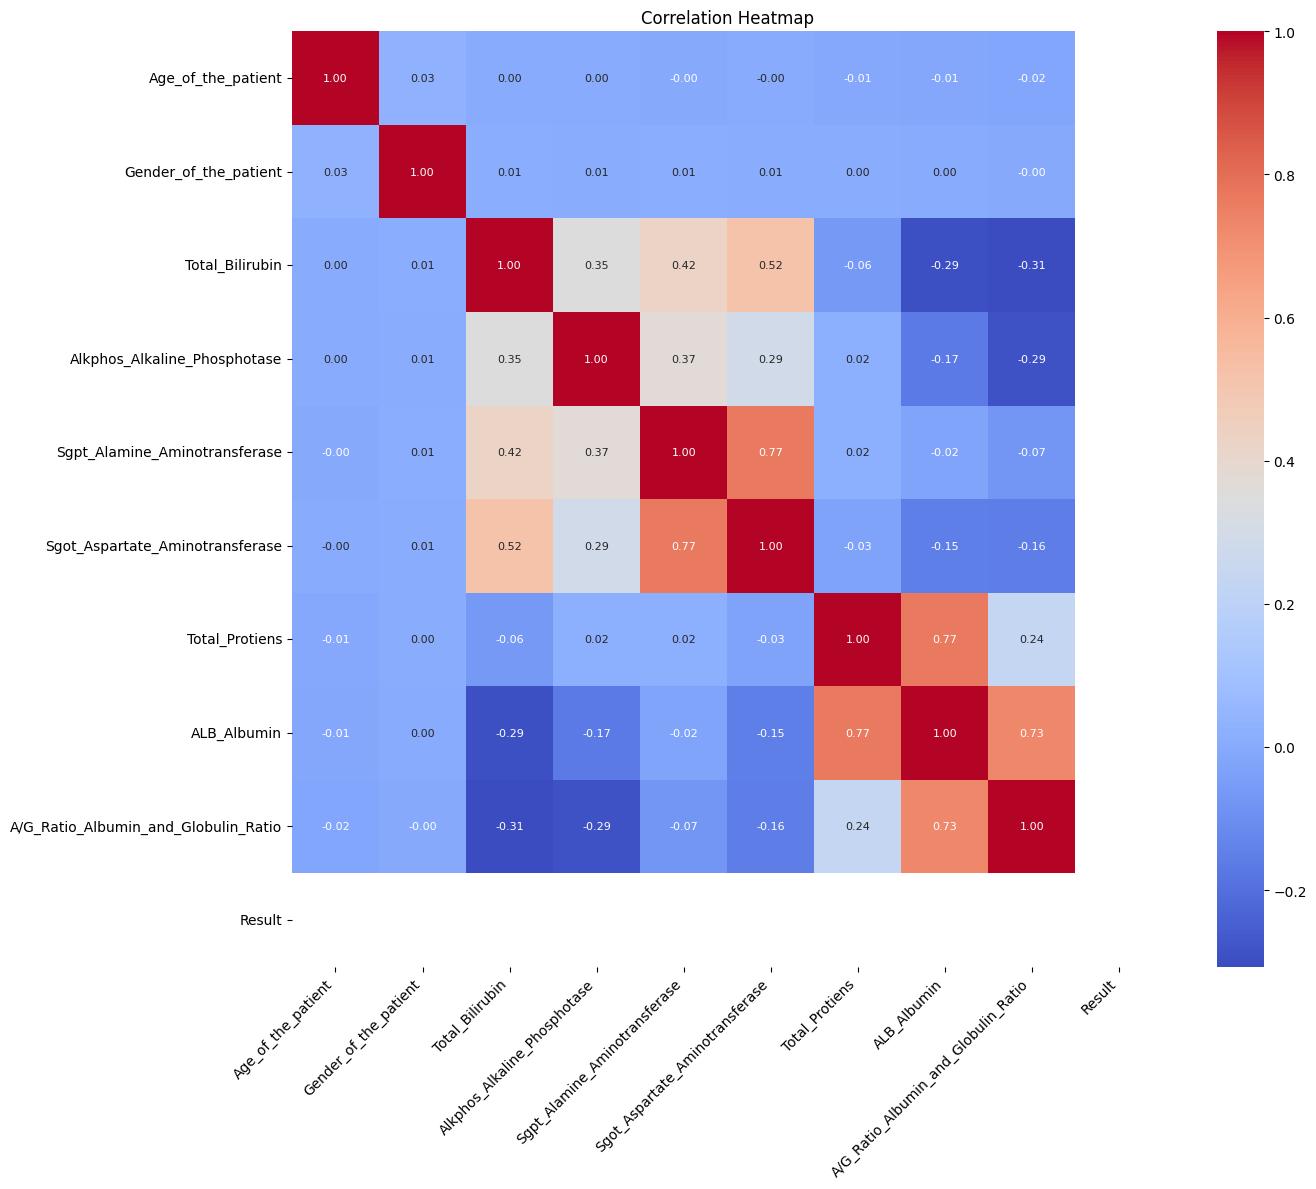

In [ ]:
plt.figure(figsize=(14, 12))

# Only numeric columns
corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    cbar=True,
    annot_kws={"size": 8}
)

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.title('Correlation Heatmap')

plt.tight_layout()

# Save image
plt.savefig("heatmap.png", dpi=300, bbox_inches='tight')

plt.show()

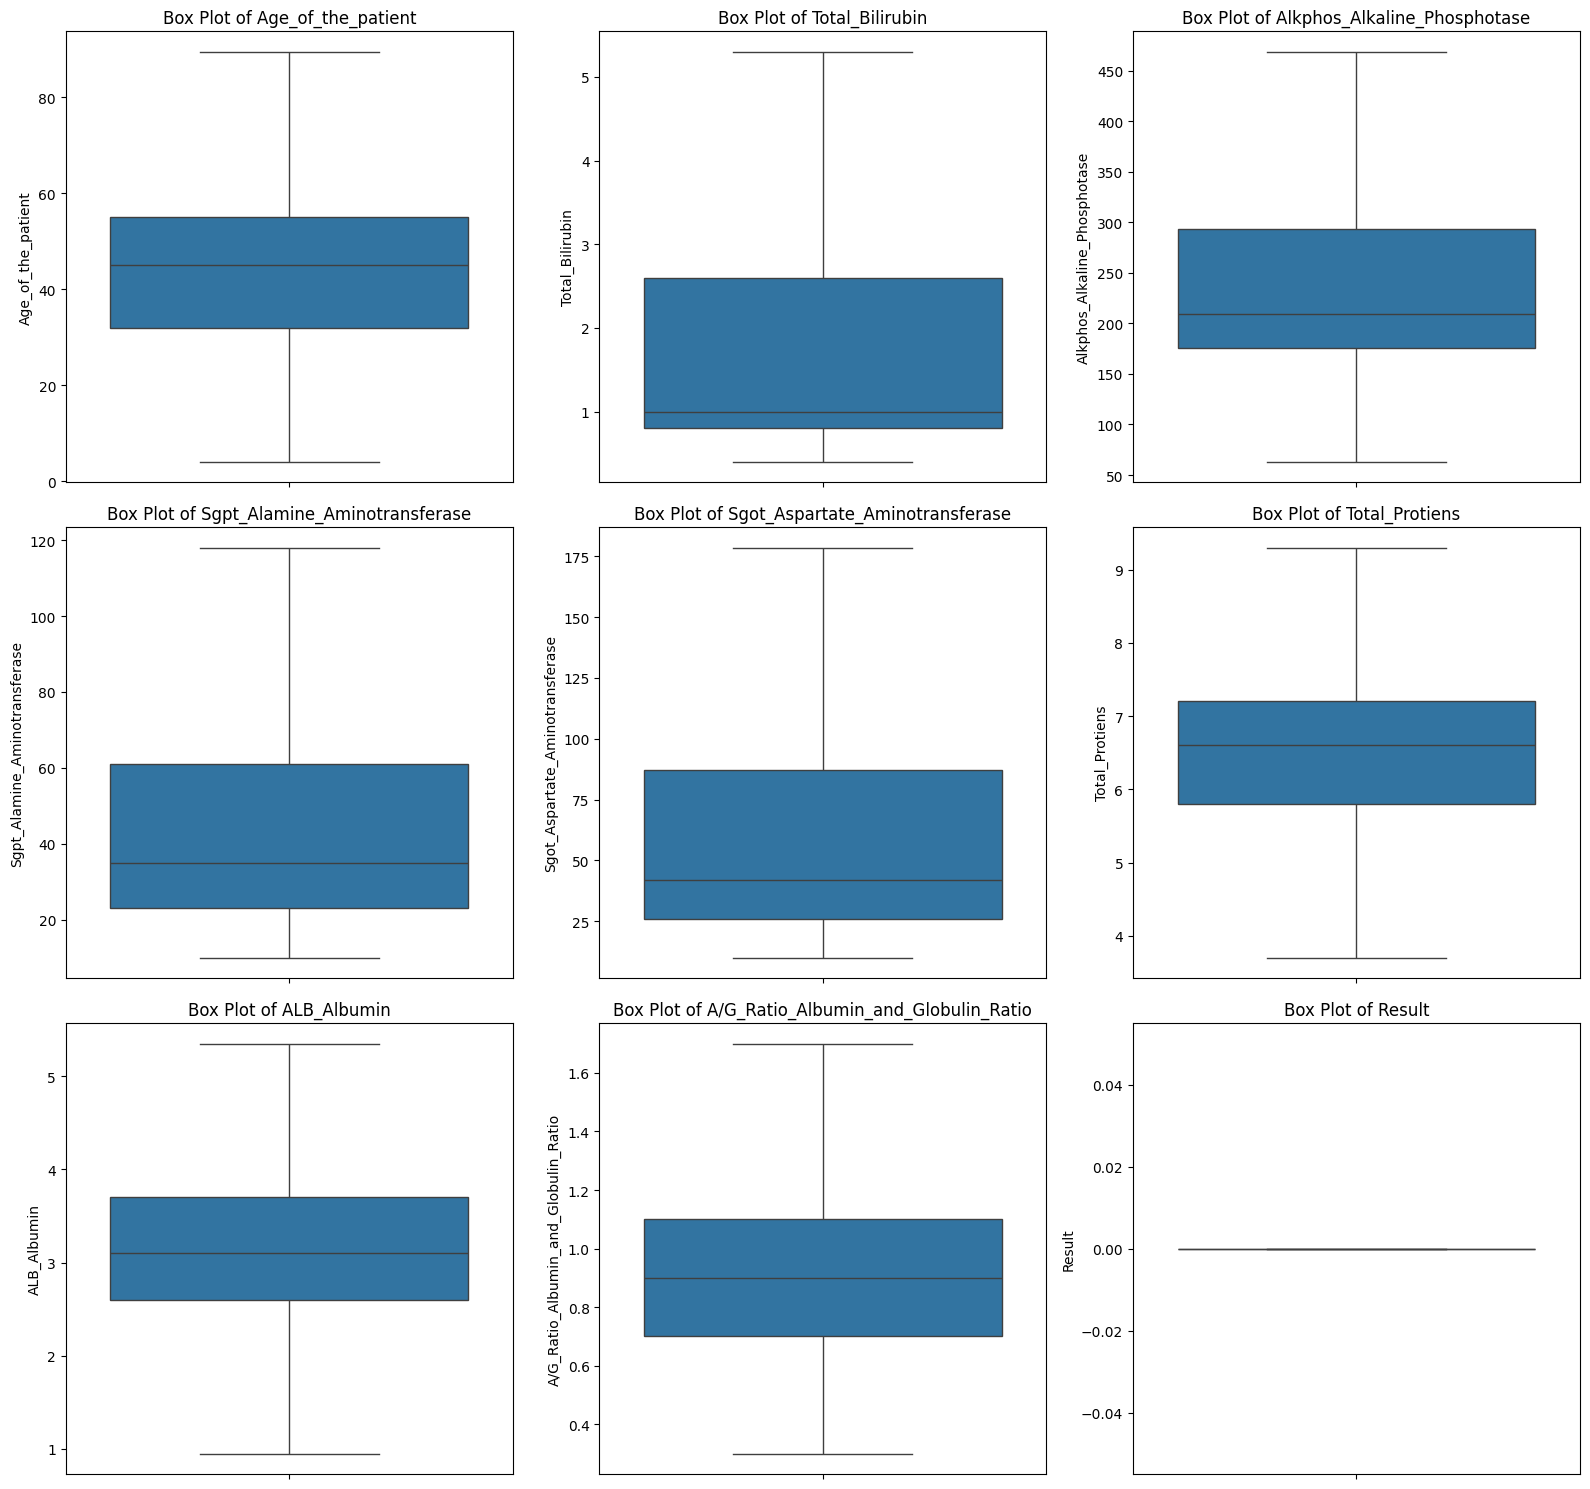

In [ ]:
num_features = df.select_dtypes(include=['float64', 'int64']).columns

n_cols = 3
n_rows = (len(num_features) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))
axes = axes.flatten()

for i, feature in enumerate(num_features):
    sns.boxplot(y=df[feature], ax=axes[i])
    axes[i].set_title(f"Box Plot of {feature}")

# Hide extra plots
for j in range(len(num_features), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()

# Save image
plt.savefig("boxplots.png", dpi=300, bbox_inches='tight')

plt.show()

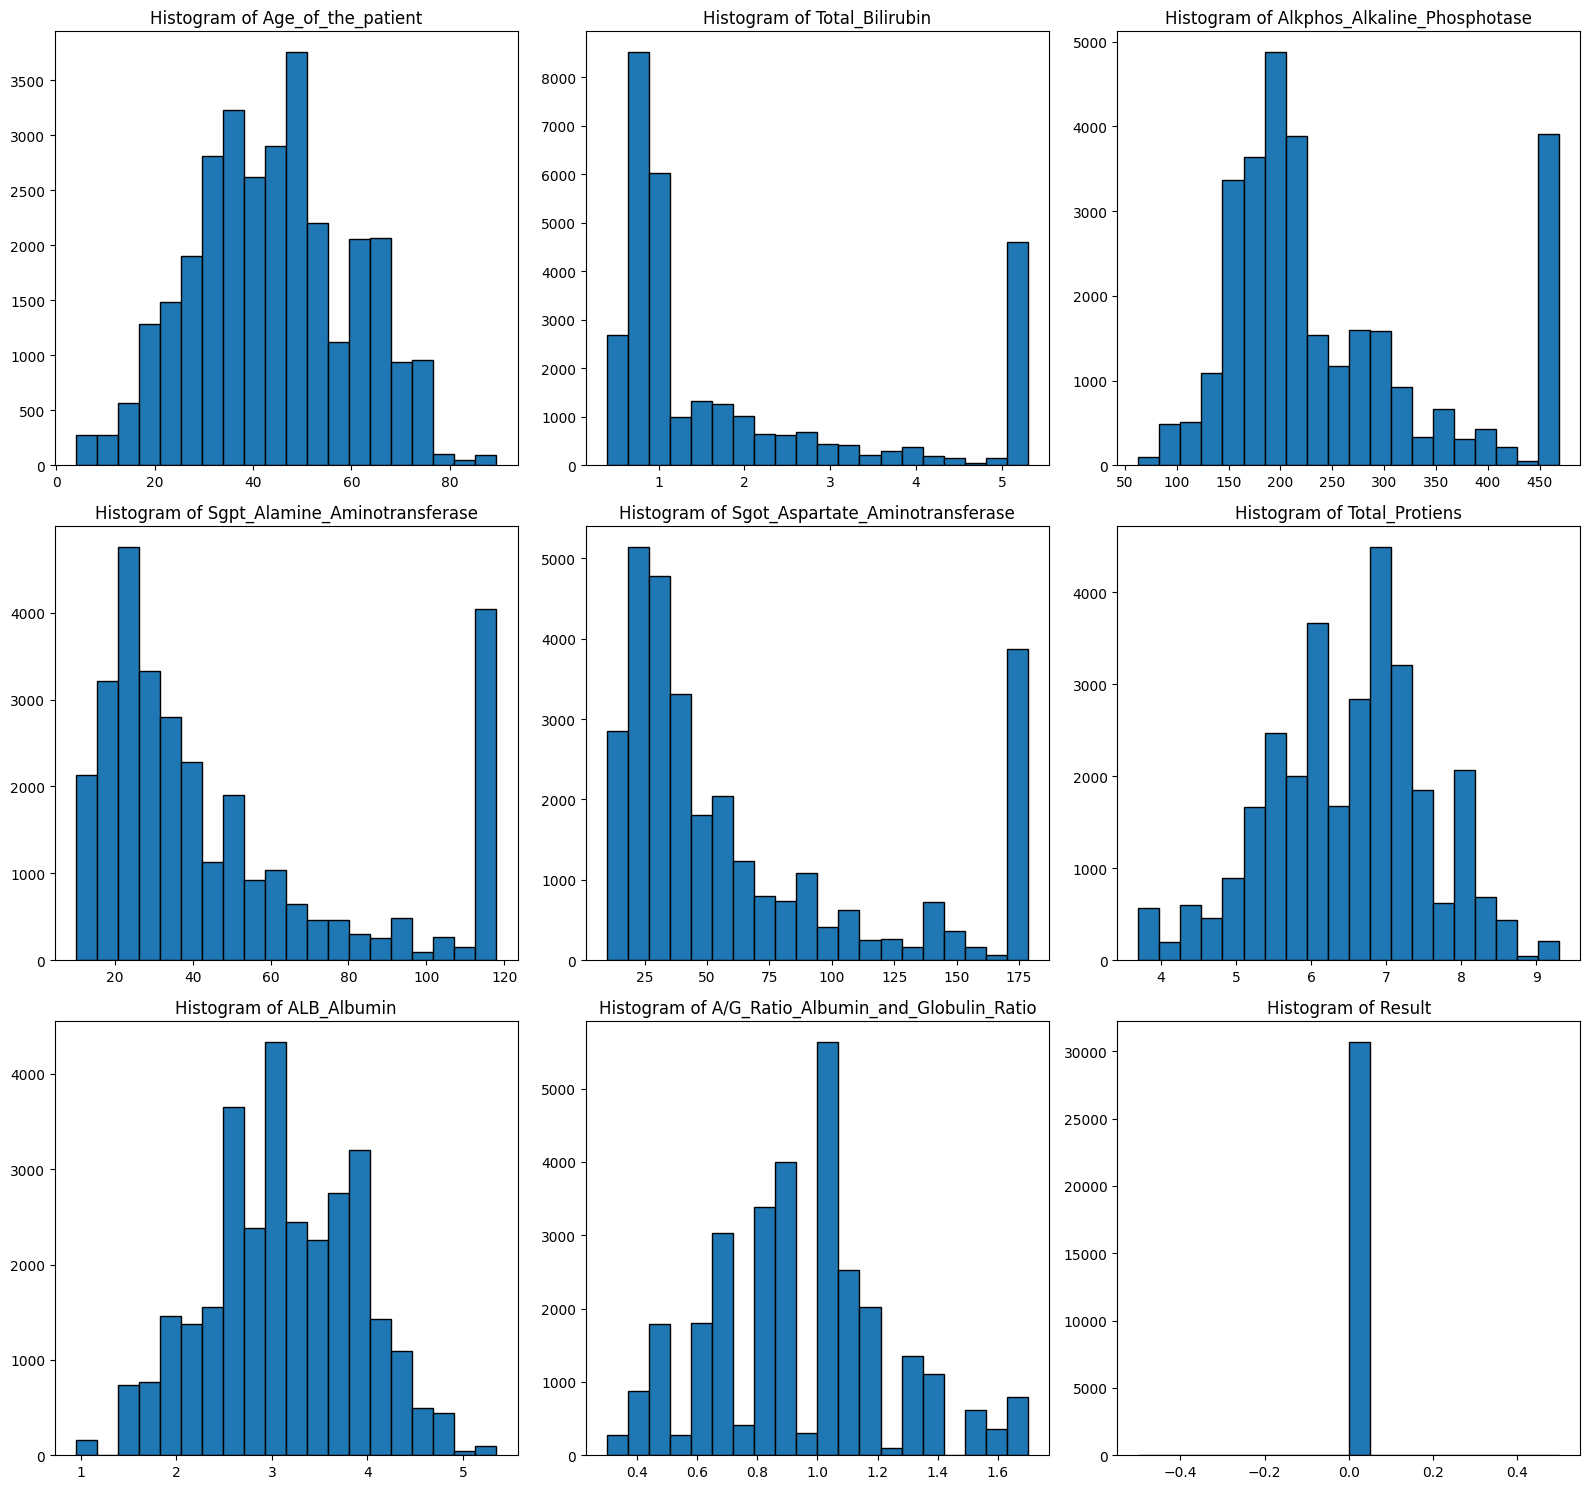

In [ ]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))
axes = axes.flatten()

for i, feature in enumerate(num_features):
    axes[i].hist(df[feature], bins=20, edgecolor='black')
    axes[i].set_title(f"Histogram of {feature}")

# Hide extra plots
for j in range(len(num_features), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()

# Save image
plt.savefig("histograms.png", dpi=300, bbox_inches='tight')

plt.show()

In [ ]:
from google.colab import files

files.download("heatmap.png")
files.download("boxplots.png")
files.download("histograms.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop('Result', axis=1)
y = df['Result']

# First split (train + temp)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Second split (val + test)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

print("Training:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Training: (24552, 9)
Validation: (3069, 9)
Test: (3070, 9)


In [ ]:
# Get numerical columns
num_features = X_train.select_dtypes(include=['float64', 'int64']).columns

# Fill using MEDIAN (better than mean)
for col in num_features:
    median_val = X_train[col].median()

    X_train[col] = X_train[col].fillna(median_val)
    X_val[col] = X_val[col].fillna(median_val)
    X_test[col] = X_test[col].fillna(median_val)

print("Missing values handled correctly (no leakage).")

Missing values handled correctly (no leakage).


In [ ]:
from sklearn.preprocessing import StandardScaler

# ------------------ OUTLIER HANDLING (IQR - BETTER THAN Z-SCORE) ------------------
def remove_outliers_iqr(df):
    df_clean = df.copy()

    for col in df_clean.select_dtypes(include=['float64', 'int64']).columns:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        df_clean[col] = np.clip(df_clean[col], lower, upper)

    return df_clean

# Apply ONLY on training data
X_train = remove_outliers_iqr(X_train)

# ------------------ SCALING ------------------
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Scaling complete.")
print("Train shape:", X_train_scaled.shape)
print("Val shape:", X_val_scaled.shape)
print("Test shape:", X_test_scaled.shape)

Scaling complete.
Train shape: (24552, 9)
Val shape: (3069, 9)
Test shape: (3070, 9)


In [ ]:
df['Result'] = df['Result'].map({1: 0, 2: 1})

In [ ]:
print("Updated classes:", df['Result'].unique())
print(df['Result'].value_counts())

Updated classes: [0 1]
Result
0    21917
1     8774
Name: count, dtype: int64


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# ------------------ SCALING ------------------
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# ------------------ MODEL ------------------
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',   # 🔥 handles imbalance properly
    random_state=42
)

model.fit(X_train_scaled, y_train)

# ------------------ VALIDATION ------------------
y_val_pred = model.predict(X_val_scaled)

print("Validation Metrics:")
print("Accuracy:", accuracy_score(y_val, y_val_pred))
print("Precision:", precision_score(y_val, y_val_pred))
print("Recall:", recall_score(y_val, y_val_pred))
print("F1 Score:", f1_score(y_val, y_val_pred))

print("\nClassification Report:\n", classification_report(y_val, y_val_pred))

Validation Metrics:
Accuracy: 0.9201694362984686
Precision: 0.9984639016897081
Recall: 0.8895985401459854
F1 Score: 0.9408926417370326

Classification Report:
               precision    recall  f1-score   support

           1       1.00      0.89      0.94      2192
           2       0.78      1.00      0.88       877

    accuracy                           0.92      3069
   macro avg       0.89      0.94      0.91      3069
weighted avg       0.94      0.92      0.92      3069



In [ ]:
y_test_pred = model.predict(X_test_scaled)

print("\nTest Metrics:")
print("Accuracy:", accuracy_score(y_test, y_test_pred))
print("Precision:", precision_score(y_test, y_test_pred))
print("Recall:", recall_score(y_test, y_test_pred))
print("F1 Score:", f1_score(y_test, y_test_pred))

print("\nFinal Classification Report:\n", classification_report(y_test, y_test_pred))


Test Metrics:
Accuracy: 0.9228013029315961
Precision: 0.9954384186517993
Recall: 0.8959854014598541
F1 Score: 0.9430972388955582

Final Classification Report:
               precision    recall  f1-score   support

           1       1.00      0.90      0.94      2192
           2       0.79      0.99      0.88       878

    accuracy                           0.92      3070
   macro avg       0.89      0.94      0.91      3070
weighted avg       0.94      0.92      0.93      3070



In [ ]:
df.head().style.set_properties(**{
    'background-color': 'white',
    'color': 'black'
})

,Age of the patient,Gender of the patient,Total Bilirubin,Alkphos Alkaline Phosphotase,Sgpt Alamine Aminotransferase,Sgot Aspartate Aminotransferase,Total Protiens,ALB Albumin,A/G Ratio Albumin and Globulin Ratio,Result
0,65.000000,0,0.700000,187.000000,16.000000,18.000000,6.800000,3.300000,0.900000,0
1,62.000000,1,5.300000,468.500000,64.000000,100.000000,7.500000,3.200000,0.740000,0
2,62.000000,1,5.300000,468.500000,60.000000,68.000000,7.000000,3.300000,0.890000,0
3,58.000000,1,1.000000,182.000000,14.000000,20.000000,6.800000,3.400000,1.000000,0
4,72.000000,1,3.900000,195.000000,27.000000,59.000000,7.300000,2.400000,0.400000,0


In [ ]:
print(df.columns.tolist())

['Age of the patient', 'Gender of the patient', 'Total Bilirubin', '\xa0Alkphos Alkaline Phosphotase', '\xa0Sgpt Alamine Aminotransferase', 'Sgot Aspartate Aminotransferase', 'Total Protiens', '\xa0ALB Albumin', 'A/G Ratio Albumin and Globulin Ratio', 'Result']


In [ ]:
df.columns = df.columns.str.strip()
df.columns = df.columns.str.replace(' ', '_')

In [ ]:
def add_features(df):
    df = df.copy()

    # Print columns once (for debugging)
    # print(df.columns)

    if 'ALB_Albumin' in df.columns and 'Total_Protiens' in df.columns:
        df['Albumin_to_Proteins_Ratio'] = df['ALB_Albumin'] / (df['Total_Protiens'] + 1e-5)

    if 'Alkphos_Alkaline_Phosphotase' in df.columns:
        df['Log_Alkphos'] = np.log1p(df['Alkphos_Alkaline_Phosphotase'])

    return df

# Apply
X_train = add_features(X_train)
X_val = add_features(X_val)
X_test = add_features(X_test)

In [ ]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

# Use scaled data (IMPORTANT)
model = LogisticRegression(max_iter=1000, random_state=42)

rfe = RFE(model, n_features_to_select=6)

rfe.fit(X_train_scaled, y_train)

# Get selected features
selected_features = X_train.columns[rfe.support_]

print("Selected Features:", selected_features.tolist())

Selected Features: ['Total Bilirubin', '\xa0Sgpt Alamine Aminotransferase', 'Sgot Aspartate Aminotransferase', 'Total Protiens', '\xa0ALB Albumin', 'A/G Ratio Albumin and Globulin Ratio']


In [ ]:
X_train_selected = X_train[selected_features]
X_val_selected = X_val[selected_features]
X_test_selected = X_test[selected_features]

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_selected = scaler.fit_transform(X_train_selected)
X_val_selected = scaler.transform(X_val_selected)
X_test_selected = scaler.transform(X_test_selected)

In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# ------------------ NAIVE BAYES ------------------
nb = GaussianNB()
nb.fit(X_train_scaled, y_train)

y_pred_nb = nb.predict(X_test_scaled)

print("Naive Bayes Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print("Precision:", precision_score(y_test, y_pred_nb))
print("Recall:", recall_score(y_test, y_pred_nb))
print("F1 Score:", f1_score(y_test, y_pred_nb))
print("\n", classification_report(y_test, y_pred_nb))


# ------------------ LOGISTIC REGRESSION ------------------
lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

print("\nLogistic Regression Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1 Score:", f1_score(y_test, y_pred_lr))
print("\n", classification_report(y_test, y_pred_lr))

Naive Bayes Results:
Accuracy: 0.6371335504885993
Precision: 0.8763966480446927
Recall: 0.572536496350365
F1 Score: 0.6926048565121413

               precision    recall  f1-score   support

           1       0.88      0.57      0.69      2192
           2       0.43      0.80      0.56       878

    accuracy                           0.64      3070
   macro avg       0.65      0.69      0.62      3070
weighted avg       0.75      0.64      0.65      3070


Logistic Regression Results:
Accuracy: 0.6429967426710098
Precision: 0.8810848400556328
Recall: 0.5780109489051095
F1 Score: 0.6980716253443526

               precision    recall  f1-score   support

           1       0.88      0.58      0.70      2192
           2       0.43      0.81      0.56       878

    accuracy                           0.64      3070
   macro avg       0.66      0.69      0.63      3070
weighted avg       0.75      0.64      0.66      3070



In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# ------------------ RANDOM FOREST ------------------
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',
    random_state=42
)

rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)

print("Random Forest:")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


# ------------------ DECISION TREE ------------------
dt = DecisionTreeClassifier(max_depth=6, random_state=42)

dt.fit(X_train_scaled, y_train)
y_pred_dt = dt.predict(X_test_scaled)

print("\nDecision Tree:")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall:", recall_score(y_test, y_pred_dt))
print("F1 Score:", f1_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))


# ------------------ XGBOOST (BEST MODEL) ------------------
y_train = y_train.map({1: 0, 2: 1})
y_test = y_test.map({1: 0, 2: 1})
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight= (y_train == 0).sum() / (y_train == 1).sum(),
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train_scaled, y_train)
y_pred_xgb = xgb.predict(X_test_scaled)

print("\nXGBoost:")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall:", recall_score(y_test, y_pred_xgb))
print("F1 Score:", f1_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

Random Forest:
Accuracy: 0.9228013029315961
Precision: 0.9954384186517993
Recall: 0.8959854014598541
F1 Score: 0.9430972388955582
              precision    recall  f1-score   support

           1       1.00      0.90      0.94      2192
           2       0.79      0.99      0.88       878

    accuracy                           0.92      3070
   macro avg       0.89      0.94      0.91      3070
weighted avg       0.94      0.92      0.93      3070


Decision Tree:
Accuracy: 0.7970684039087947
Precision: 0.7860007291286912
Recall: 0.9835766423357665
F1 Score: 0.873758865248227
              precision    recall  f1-score   support

           1       0.79      0.98      0.87      2192
           2       0.89      0.33      0.48       878

    accuracy                           0.80      3070
   macro avg       0.84      0.66      0.68      3070
weighted avg       0.82      0.80      0.76      3070


XGBoost:
Accuracy: 0.9928338762214983
Precision: 0.9852607709750567
Recall: 0.9897494

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# ------------------ CHECK LABELS ------------------
print("Unique labels in y_train:", y_train.unique())
print("NaN in y_train:", y_train.isnull().sum())

# If labels are already 0/1 → use directly
y_train_svm = y_train.copy()
y_test_svm = y_test.copy()

# ------------------ MODEL ------------------
svm = SVC(
    kernel='rbf',
    C=1,
    gamma='scale',
    class_weight='balanced',   # handles imbalance
    random_state=42
)

# IMPORTANT: use scaled data
svm.fit(X_train_scaled, y_train_svm)

# ------------------ PREDICTION ------------------
y_pred_svm = svm.predict(X_test_scaled)

# ------------------ METRICS ------------------
print("\nSVM Results:")
print("Accuracy:", accuracy_score(y_test_svm, y_pred_svm))
print("Precision:", precision_score(y_test_svm, y_pred_svm))
print("Recall:", recall_score(y_test_svm, y_pred_svm))
print("F1 Score:", f1_score(y_test_svm, y_pred_svm))

print("\nClassification Report:\n", classification_report(y_test_svm, y_pred_svm))

Unique labels in y_train: [1 0]
NaN in y_train: 0

SVM Results:
Accuracy: 0.721172638436482
Precision: 0.5065398335315101
Recall: 0.9703872437357631
F1 Score: 0.665625

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.62      0.76      2192
           1       0.51      0.97      0.67       878

    accuracy                           0.72      3070
   macro avg       0.74      0.80      0.71      3070
weighted avg       0.85      0.72      0.73      3070



In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# ------------------ MODEL ------------------
mlp = MLPClassifier(random_state=42)

# Parameter grid
param_grid = {
    'hidden_layer_sizes': [(50,), (100,), (100,50)],
    'activation': ['relu', 'tanh'],
    'max_iter': [200],
    'learning_rate': ['constant', 'adaptive']
}

# Grid search using TRAIN data only
grid_search = GridSearchCV(
    mlp,
    param_grid,
    cv=3,
    scoring='accuracy',
    verbose=1
)

# IMPORTANT: use scaled data
grid_search.fit(X_train_scaled, y_train)

print("\nBest Parameters:", grid_search.best_params_)

best_mlp = grid_search.best_estimator_

# ------------------ TEST EVALUATION ------------------
y_pred_mlp = best_mlp.predict(X_test_scaled)

print("\nMLP Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_mlp))
print("Precision:", precision_score(y_test, y_pred_mlp))
print("Recall:", recall_score(y_test, y_pred_mlp))
print("F1 Score:", f1_score(y_test, y_pred_mlp))

print("\nClassification Report:\n", classification_report(y_test, y_pred_mlp))

Fitting 3 folds for each of 12 candidates, totalling 36 fits


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptro


Best Parameters: {'activation': 'tanh', 'hidden_layer_sizes': (100, 50), 'learning_rate': 'constant', 'max_iter': 200}

MLP Results:
Accuracy: 0.9895765472312703
Precision: 0.9862068965517241
Recall: 0.9772209567198178
F1 Score: 0.9816933638443935

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99      2192
           1       0.99      0.98      0.98       878

    accuracy                           0.99      3070
   macro avg       0.99      0.99      0.99      3070
weighted avg       0.99      0.99      0.99      3070



/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


MLP Test Accuracy: 0.9895765472312703
MLP Precision: 0.9862068965517241
MLP Recall: 0.9772209567198178
MLP F1 Score: 0.9816933638443935

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99      2192
           1       0.99      0.98      0.98       878

    accuracy                           0.99      3070
   macro avg       0.99      0.99      0.99      3070
weighted avg       0.99      0.99      0.99      3070



In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def get_metrics(model, X_test, y_test):
    y_pred = model.predict(X_test)

    # Convert both to pandas Series
    y_test = pd.Series(y_test)
    y_pred = pd.Series(y_pred)

    # Force both to binary safely
    y_test = y_test.replace({2: 1})
    y_pred = y_pred.replace({2: 1})

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='binary')
    recall = recall_score(y_test, y_pred, average='binary')
    f1 = f1_score(y_test, y_pred, average='binary')

    # AUC
    auc = None
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_prob)

    return accuracy, precision, recall, f1, auc

In [ ]:
results = []

for name, model in model_list:
    acc, prec, rec, f1, auc = get_metrics(model, X_test_scaled, y_test)
    results.append([name, acc, prec, rec, f1, auc])

In [ ]:
import pandas as pd

results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "F1 Score", "AUC"])
results_df = results_df.sort_values(by="F1 Score", ascending=False)

print(results_df)

                 Model  Accuracy  Precision    Recall  F1 Score       AUC
4              XGBoost  0.992834   0.985261  0.989749  0.987500  0.999144
6                  MLP  0.989577   0.986207  0.977221  0.981693  0.995229
5                  SVM  0.721173   0.506540  0.970387  0.665625       NaN
2        Random Forest  0.285993   0.285993  1.000000  0.444782  0.997477
1  Logistic Regression  0.285993   0.285993  1.000000  0.444782  0.747364
0          Naive Bayes  0.285993   0.285993  1.000000  0.444782  0.736380
3        Decision Tree  0.285993   0.285993  1.000000  0.444782  0.850967


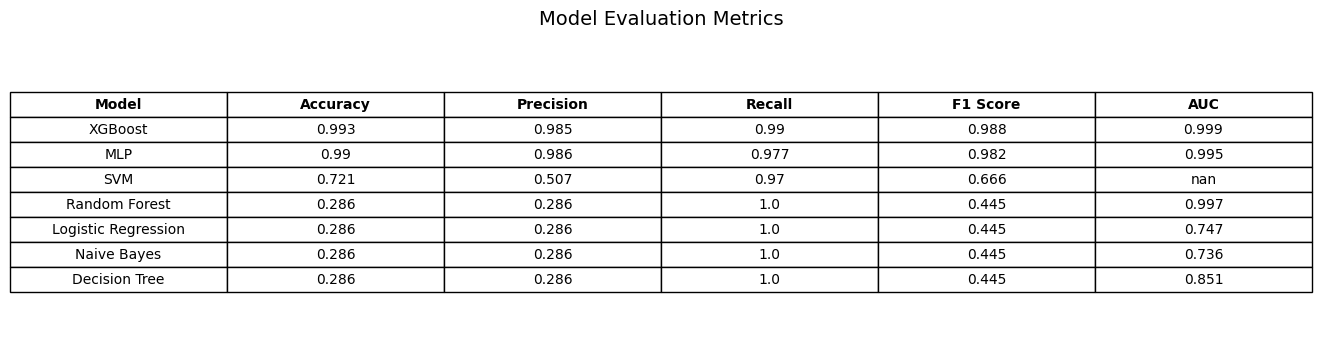

In [ ]:
import matplotlib.pyplot as plt

# Ensure correct dataframe
df_metrics = results_df.copy()

fig, ax = plt.subplots(figsize=(14, 4))  # slightly bigger for clarity
ax.axis('off')

table = ax.table(
    cellText=df_metrics.round(3).values,
    colLabels=df_metrics.columns,
    loc='center',
    cellLoc='center'
)

# Styling
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)

# Bold header
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_text_props(weight='bold')

plt.title("Model Evaluation Metrics", fontsize=14, pad=10)

plt.savefig("evaluation_metrics_table.png", bbox_inches='tight', dpi=300)
plt.show()

In [ ]:
from google.colab import files
files.download("evaluation_metrics_table.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

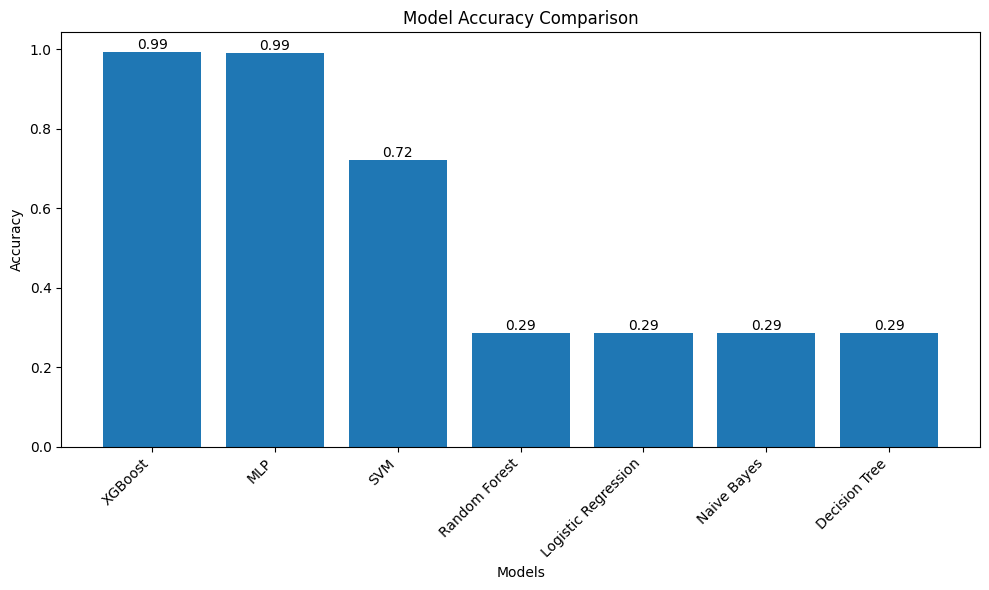

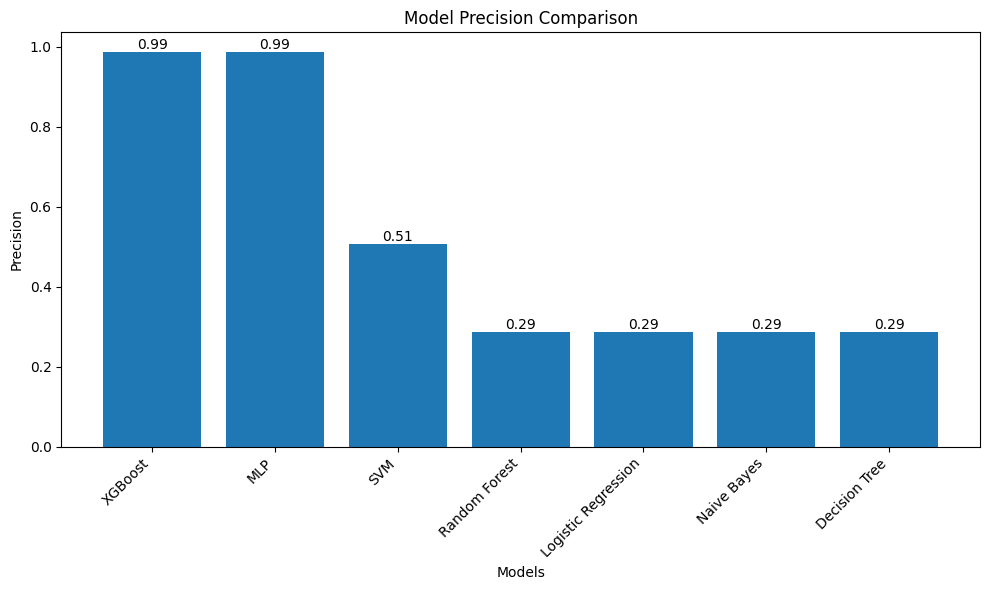

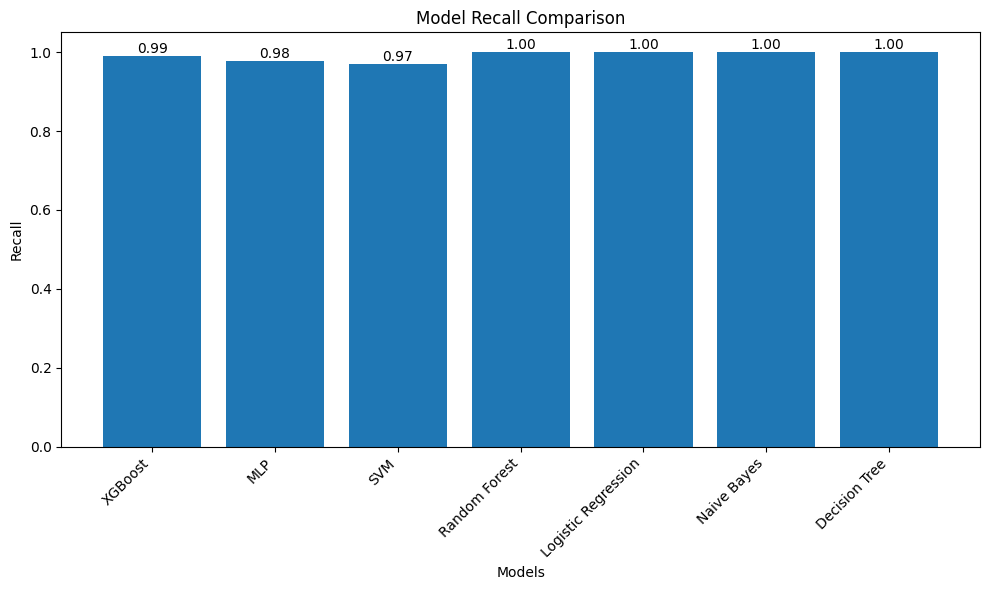

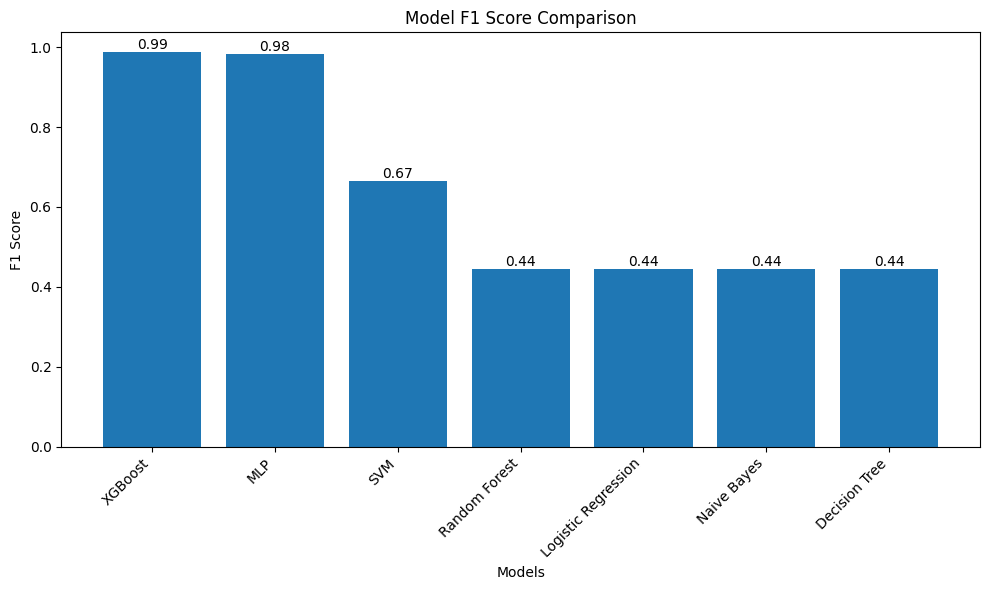

In [ ]:
import matplotlib.pyplot as plt

# Use final results
df_plot = results_df.copy()

models = df_plot["Model"]
accuracy = df_plot["Accuracy"]
precision = df_plot["Precision"]
recall = df_plot["Recall"]
f1 = df_plot["F1 Score"]

# ------------------ FUNCTION ------------------
def plot_bar(x, y, title, ylabel, filename):
    plt.figure(figsize=(10, 6))
    bars = plt.bar(x, y)

    plt.title(title)
    plt.xlabel("Models")
    plt.ylabel(ylabel)
    plt.xticks(rotation=45, ha='right')

    # values on bars
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval,
                 f'{yval:.2f}', ha='center', va='bottom')

    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()

# ------------------ PLOTS ------------------

plot_bar(models, accuracy, "Model Accuracy Comparison", "Accuracy", "accuracy.png")
plot_bar(models, precision, "Model Precision Comparison", "Precision", "precision.png")
plot_bar(models, recall, "Model Recall Comparison", "Recall", "recall.png")
plot_bar(models, f1, "Model F1 Score Comparison", "F1 Score", "f1_score.png")

In [ ]:
from google.colab import files

files.download("accuracy.png")
files.download("precision.png")
# files.download("recall.png")
# files.download("f1_score.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>